# Advanced-1. Exploring Precalculated Hamiltonians

In this chapter, we are going to show that the **classical exact solving** quickly becomes the bottleneck.

1. load a library of **precomputed qubit Hamiltonians**,  
2. inspect how the problem size grows with the molecular system,  
3. and compare that growth with the cost of **exact diagonalization**.

In [1]:
from utils import load_sparse_pauli_ops_from_pickle
import numpy as np
import matplotlib.pyplot as plt
from time import time

## A1-1. Load the Precomputed Hamiltonians

![hydrogen_chain.png](images/hydrogen_chain.png)

We load a collection of precalculated qubit Hamiltonians for linear hydrogen chains.
Each entry is already stored as a `SparsePauliOp`, so we can immediately inspect:

- the number of qubits,
- the number of Pauli terms,
- and a concrete small example such as `H2`.

This separates **Hamiltonian generation** from **Hamiltonian analysis**.


In [2]:
loaded_ham = load_sparse_pauli_ops_from_pickle("linear_h_chains_jw.json")
available = sorted(loaded_ham.keys(), key=lambda name: int(name[1:]))

print("Available molecules:", available)

example = "H2"
ham = loaded_ham[example]
print(f"\n{example}:")
print(f"  n_qubits = {ham.num_qubits}")
print(f"  n_terms  = {len(ham)}")
print(ham)


Available molecules: ['H2', 'H3', 'H4', 'H5', 'H6', 'H7']

H2:
  n_qubits = 4
  n_terms  = 15
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'YXXY', 'XXYY', 'YYXX', 'XYYX', 'IZIZ', 'ZIIZ', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.09886397+0.j,  0.17119775+0.j,  0.17119775+0.j, -0.22278593+0.j,
 -0.22278593+0.j,  0.16862219+0.j,  0.0453222 +0.j, -0.0453222 +0.j,
 -0.0453222 +0.j,  0.0453222 +0.j,  0.12054482+0.j,  0.16586702+0.j,
  0.16586702+0.j,  0.12054482+0.j,  0.17434844+0.j])


## A1-2. Exact Diagonalization as a Reference

For small systems, we can still convert the Pauli Hamiltonian into a dense matrix and compute
its exact spectrum with `numpy.linalg.eigh`.

That is useful as a **reference calculation**, but it is not scalable:
if the Hamiltonian acts on $n$ qubits, then the dense matrix has dimension
$$
2^n \times 2^n.
$$

So in this notebook we use exact diagonalization only to illustrate the scaling trend.
By default we stop at `H6` to keep the runtime lightweight.


In [3]:
def exact_ground_state_energy(hamiltonian):
    mat = np.array(hamiltonian)
    evals, _ = np.linalg.eigh(mat)
    return float(np.min(evals)), mat.shape[0]

max_chain_to_diagonalize = 7
results = []

for name in available:
    n_chain = int(name[1:])
    ham = loaded_ham[name]

    entry = {
        "name": name,
        "n_chain": n_chain,
        "n_qubits": ham.num_qubits,
        "n_terms": len(ham),
    }

    if n_chain <= max_chain_to_diagonalize:
        print(f"Diagonalizing {name} ...")
        t0 = time()
        energy, dim = exact_ground_state_energy(ham)
        elapsed = time() - t0

        entry["dimension"] = dim
        entry["ground_energy"] = energy
        entry["solve_time"] = elapsed

        print(f"  n_qubits = {ham.num_qubits}")
        print(f"  n_terms  = {len(ham)}")
        print(f"  matrix dimension = {dim}")
        print(f"  exact ground-state energy = {energy:.10f}")
        print(f"  wall time = {elapsed:.3f} s\n")
    else:
        entry["dimension"] = 2 ** ham.num_qubits
        entry["ground_energy"] = None
        entry["solve_time"] = None
        print(f"Skipping exact diagonalization for {name} to avoid a long runtime.\n")

    results.append(entry)


Diagonalizing H2 ...
  n_qubits = 4
  n_terms  = 15
  matrix dimension = 16
  exact ground-state energy = -1.1372701747
  wall time = 0.001 s

Diagonalizing H3 ...
  n_qubits = 6
  n_terms  = 62
  matrix dimension = 64
  exact ground-state energy = -1.5269470051
  wall time = 0.001 s

Diagonalizing H4 ...
  n_qubits = 8
  n_terms  = 185
  matrix dimension = 256
  exact ground-state energy = -2.1397996447
  wall time = 0.115 s

Diagonalizing H5 ...
  n_qubits = 10
  n_terms  = 444
  matrix dimension = 1024
  exact ground-state energy = -2.5582083208
  wall time = 0.952 s

Diagonalizing H6 ...
  n_qubits = 12
  n_terms  = 919
  matrix dimension = 4096
  exact ground-state energy = -3.1442468941
  wall time = 35.668 s

Diagonalizing H7 ...
  n_qubits = 14
  n_terms  = 1702
  matrix dimension = 16384
  exact ground-state energy = -3.5806988891
  wall time = 2058.079 s



## A1-3. Visualize the Growth

We now compare several quantities as the chain length increases:

- number of qubits,
- number of Pauli terms,
- Hilbert-space dimension $2^n$,
- and exact diagonalization time for the systems we actually solved.

The first three are structural properties of the Hamiltonian.
The last one reflects the classical cost of solving it exactly.


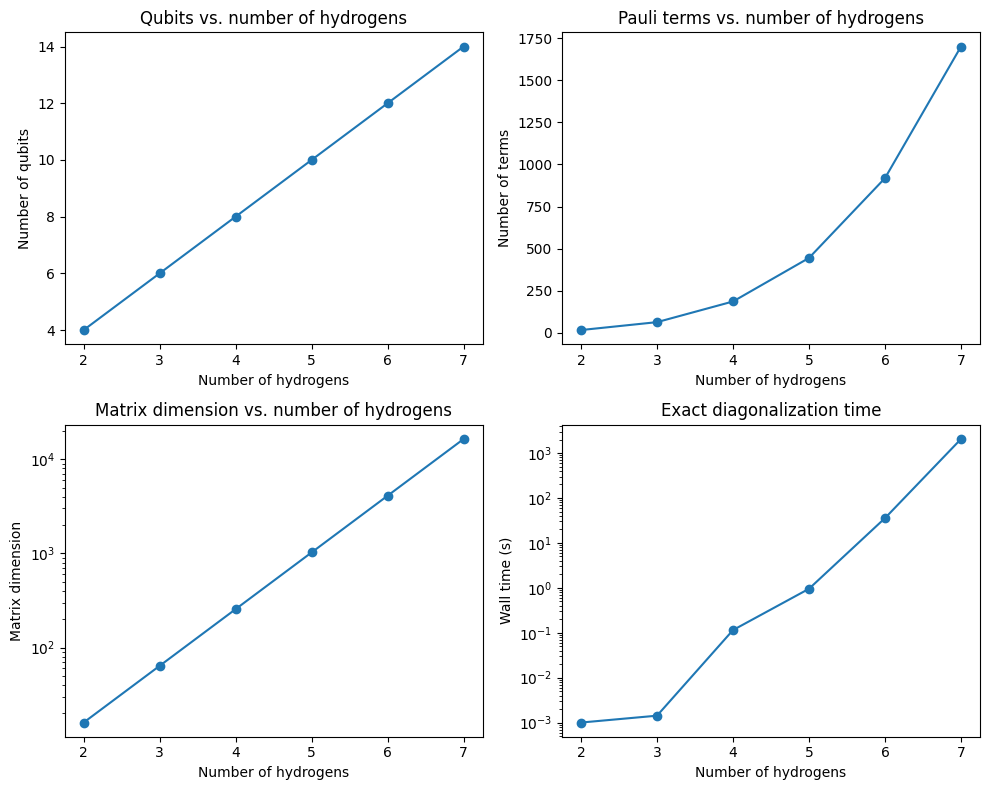

In [4]:
n_chain_list = [r["n_chain"] for r in results]
n_qubits_list = [r["n_qubits"] for r in results]
n_terms_list = [r["n_terms"] for r in results]
dimensions_list = [r["dimension"] for r in results]

timed_results = [r for r in results if r["solve_time"] is not None]
timed_n_chain = [r["n_chain"] for r in timed_results]
timed_solve_time = [r["solve_time"] for r in timed_results]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].plot(n_chain_list, n_qubits_list, marker="o")
axs[0, 0].set_title("Qubits vs. number of hydrogens")
axs[0, 0].set_xlabel("Number of hydrogens")
axs[0, 0].set_ylabel("Number of qubits")

axs[0, 1].plot(n_chain_list, n_terms_list, marker="o")
axs[0, 1].set_title("Pauli terms vs. number of hydrogens")
axs[0, 1].set_xlabel("Number of hydrogens")
axs[0, 1].set_ylabel("Number of terms")

axs[1, 0].plot(n_chain_list, dimensions_list, marker="o")
axs[1, 0].set_title("Matrix dimension vs. number of hydrogens")
axs[1, 0].set_xlabel("Number of hydrogens")
axs[1, 0].set_ylabel("Matrix dimension")
axs[1, 0].set_yscale("log")

axs[1, 1].plot(timed_n_chain, timed_solve_time, marker="o")
axs[1, 1].set_title("Exact diagonalization time")
axs[1, 1].set_xlabel("Number of hydrogens")
axs[1, 1].set_ylabel("Wall time (s)")
axs[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()


## A1-4. Interpretation

The main message is the contrast between two kinds of cost:

1. **storing the Hamiltonian as a Pauli sum**, and  
2. **solving the Hamiltonian exactly as a dense matrix problem**.

Even when the Hamiltonian is already available in a compact Pauli representation,
the full Hilbert-space dimension still grows exponentially with the number of qubits.
That is why exact diagonalization becomes impractical much sooner than simple Hamiltonian inspection.

This is precisely the regime where variational methods or sampled-subspace methods become useful:
they try to extract low-energy information **without** solving the full $2^n$-dimensional problem.


------